# Traditional model: Naive Bayes
### Implemented by: Junior Chaj Mejia

### Collect packages

In [3]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import pandas as pd
import scipy.sparse as sparse
import seaborn as sns

### Load data sets, features, and labels

Note this notebook exists under the `notebook` directory. The preprocessed data sets exist under the `data` direectory.

```text
.
├── data
├── models
├── notebooks
└── results
```

In [4]:
# Load data set
training_set = pd.read_csv('../data/train_processed.csv')
validation_set = pd.read_csv('../data/val_processed.csv')
testing_set = pd.read_csv('../data/test_processed.csv')

# Load features
training_features = sparse.load_npz('../data/tfidf_train.npz')
validation_features = sparse.load_npz('../data/tfidf_val.npz')
testing_features = sparse.load_npz('../data/tfidf_test.npz')

# Load labels
training_labels = training_set['label']
validation_labels = validation_set['label']
testing_labels = testing_set['label']
emotion_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

### Configure model
Tune smoothing parameter alpha

In [5]:
best_alpha = None
best_f1 = -1

for alpha in [0.1, 0.5, 1.0, 2.0]:
    tune_model = MultinomialNB(alpha=alpha)
    tune_model.fit(training_features, training_labels)
    
    preds = tune_model.predict(validation_features)
    score = f1_score(validation_labels, preds, average='macro')
    
    print(f'alpha={alpha}, val_macro_f1={round(score, 4)}')
    
    if score > best_f1:
        best_f1 = score
        best_alpha = alpha

print(f'Best alpha selected: {best_alpha}')

# Instantiate model with laplace smoothing
model = MultinomialNB(alpha=best_alpha)
model.fit(training_features, training_labels)

alpha=0.1, val_macro_f1=0.7751
alpha=0.5, val_macro_f1=0.6925
alpha=1.0, val_macro_f1=0.5691
alpha=2.0, val_macro_f1=0.4551
Best alpha selected: 0.1


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Validation helper function

In [6]:
def evaluate(labels, predictions, set='', dec=4):
    acc = round(accuracy_score(labels, predictions), dec)
    macro_f1 = round(f1_score(labels, predictions, average='macro'), dec)
    precis = round(precision_score(labels, predictions, average='macro'), dec)
    recall = round(recall_score(labels, predictions, average='macro'), dec)
    print(f'{set} Accuracy: {acc}')
    print(f'{set} Macro F1: {macro_f1}')
    print(f'{set} Precision: {precis}')
    print(f'{set} Recall: {recall}')

### Evaluate on validation and testing predictions

In [7]:
# Evaluate on validation predictions
validation_predictions = model.predict(validation_features)
evaluate(validation_labels, validation_predictions, set='Validation', dec=4)

# Evaluate on testing predictions
testing_predictions = model.predict(testing_features)
evaluate(testing_labels, testing_predictions, set='Test', dec=4)

# Output evaluation metrics
print(classification_report(testing_labels, testing_predictions, target_names=emotion_labels))

Validation Accuracy: 0.8365
Validation Macro F1: 0.7751
Validation Precision: 0.8535
Validation Recall: 0.7322
Test Accuracy: 0.836
Test Macro F1: 0.7396
Test Precision: 0.8515
Test Recall: 0.6935
              precision    recall  f1-score   support

     sadness       0.84      0.93      0.88       581
         joy       0.80      0.96      0.87       695
        love       0.86      0.51      0.64       159
       anger       0.90      0.75      0.82       275
        fear       0.88      0.74      0.80       224
    surprise       0.83      0.29      0.43        66

    accuracy                           0.84      2000
   macro avg       0.85      0.69      0.74      2000
weighted avg       0.84      0.84      0.83      2000



### Present confusion matrix

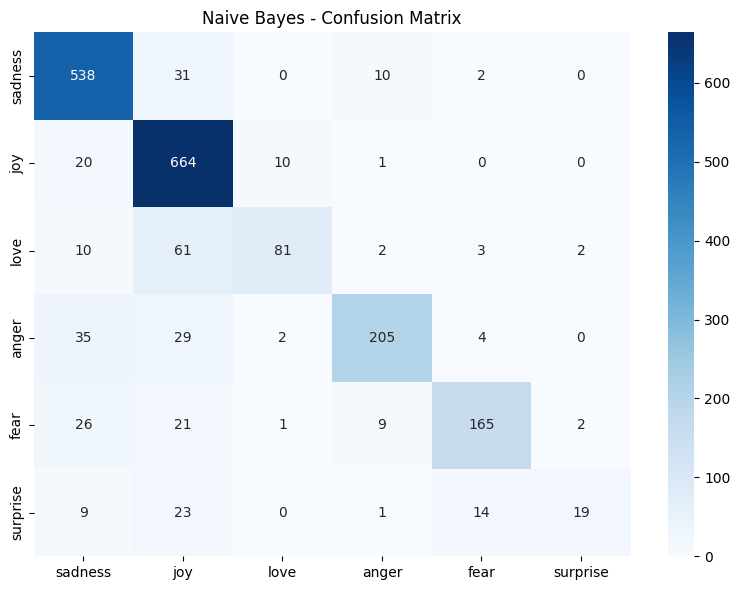

In [8]:
confusion = confusion_matrix(testing_labels, testing_predictions)
plt.figure(figsize=(8, 6))
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.tight_layout()
plt.savefig("../results/naive_bayes_confusion_matrix.png")
plt.show()